# Partitioning: the photos on several machines

The photo service stores 40,000 photos. When one machine is not enough, the rows are split
over several machines (nodes). How the rows are split decides how even the load is, and how
many nodes each query must ask.

In [1]:
NODES = 4  # the number of machines (parameter: change it and run all cells again)

In [2]:
import bisect
import hashlib
import re
from pathlib import Path

import altair as alt
import duckdb
import numpy as np
import pandas as pd

import photo_data
from photo_data import viz

viz.enable()
alt.renderers.enable("png", scale_factor=2)
photos = photo_data.photos()
len(photos)

40000

## 1. Three ways to split the rows (horizontal partitioning)

- by a hash of the user: all photos of a user are on the same node;
- by ranges of the upload month: consecutive months on the same node;
- by a hash of the photo id.

In [3]:
def stable_hash(key) -> int:
    """The same number for the same key on every machine (unlike Python's hash())."""
    return int(hashlib.md5(str(key).encode()).hexdigest()[:8], 16)


months = sorted(photos.upload_date.dt.strftime("%Y-%m").unique())
groups = np.array_split(months[:6], NODES)  # July to December, in NODES ranges
month_node = {m: i for i, g in enumerate(groups) for m in g} | {m: NODES - 1 for m in months[6:]}
node = {
    "hash of the user": photos.user_id.map(lambda u: stable_hash(u) % NODES),
    "range of the month": photos.upload_date.dt.strftime("%Y-%m").map(month_node),
    "hash of the photo id": photos.photo_id.map(lambda p: stable_hash(p) % NODES),
}
last_week = photos.upload_date >= "2021-12-25"
rows = []
for strategy, n in node.items():
    for label, mask in [("all photos", slice(None)), ("uploads of the last week", last_week)]:
        counts = n[mask].value_counts().reindex(range(NODES), fill_value=0)
        rows += [
            {"strategy": strategy, "what": label, "node": f"node {i + 1}", "photos": c}
            for i, c in counts.items()
        ]
parts = pd.DataFrame(rows)
summary = parts.groupby(["what", "strategy"], sort=False).photos.agg(["max", "mean"])
summary["largest / mean"] = (summary["max"] / summary["mean"]).round(2)
summary

,,max,mean,largest / mean
what,strategy,,,
all photos,hash of the user,12255,10000.0,1.23
uploads of the last week,hash of the user,720,578.0,1.25
all photos,range of the month,16016,10000.0,1.60
uploads of the last week,range of the month,2312,578.0,4.00
all photos,hash of the photo id,10116,10000.0,1.01
uploads of the last week,hash of the photo id,605,578.0,1.05


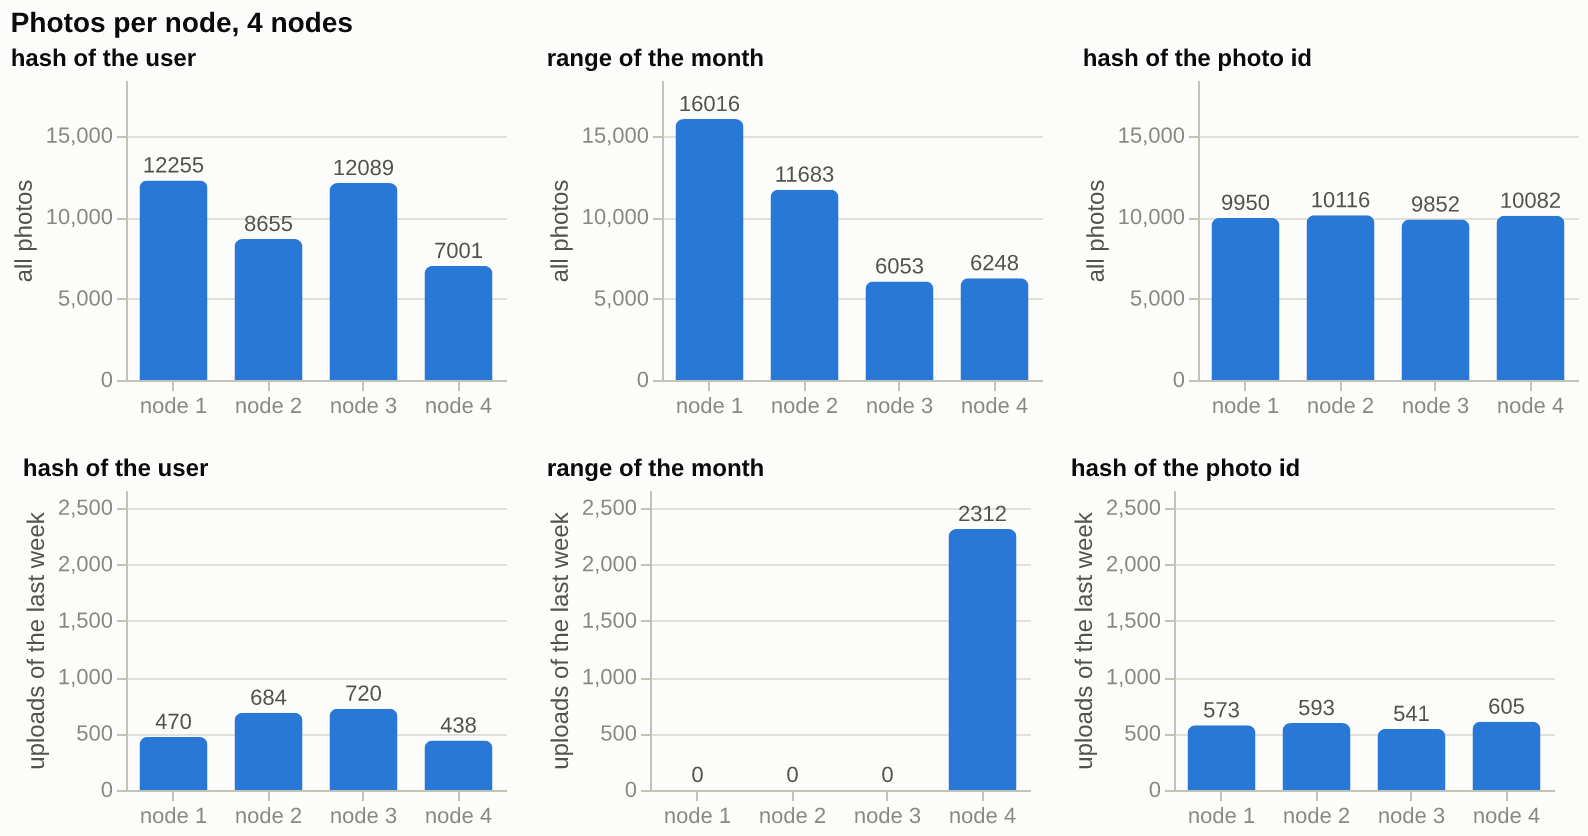

In [4]:
def bars(strategy: str, what: str, y_max: int) -> alt.LayerChart:
    data = parts[(parts.strategy == strategy) & (parts.what == what)]
    base = alt.Chart(data, title=alt.Title(strategy, fontSize=12)).encode(
        x=alt.X("node:N", title=None, axis=alt.Axis(labelAngle=0)),
        y=alt.Y("photos:Q", title=what, scale=alt.Scale(domain=[0, y_max])),
    )
    return (
        base.mark_bar(color=viz.SERIES[0], size=34)
        + base.mark_text(dy=-7, color=viz.INK_2, fontSize=11).encode(text="photos:Q")
    ).properties(width=190, height=150)


alt.vconcat(
    *[
        alt.hconcat(*[bars(s, w, int(parts[parts.what == w].photos.max() * 1.15)) for s in node])
        for w in ["all photos", "uploads of the last week"]
    ]
).properties(title=f"Photos per node, {NODES} nodes")

With the user as the key, the nodes are not equal: all 5,124 photos of the most active
user (`ckaestne`) are on one node. With ranges of months, the sizes depend on the chosen
ranges and the season (the first node has the summer months July and August), and all new
uploads go to the last node: it gets all the writes (a hot spot). The hash of the photo id
spreads the photos evenly.

## 2. Which nodes must answer a query?

A query must ask each node that can have matching rows (fan-out).

In [5]:
queries = {
    "the photos of ckaestne": photos.user_id == 54351,
    "the photos uploaded on 2021-12-03": photos.upload_date.dt.strftime("%Y-%m-%d") == "2021-12-03",
    "the photo 133422131": photos.photo_id == 133422131,
}
pd.DataFrame(
    {s: {q: n[mask].nunique() for q, mask in queries.items()} for s, n in node.items()}
).rename_axis("nodes to ask")

,hash of the user,range of the month,hash of the photo id
nodes to ask,,,
the photos of ckaestne,1,4,4
the photos uploaded on 2021-12-03,4,1,4
the photo 133422131,1,1,1


Each key is good for the queries that use it: the user key for the library of one user,
the month for the photos of one day, the photo id for one photo. A query without the key
must ask all nodes.

## 3. A fifth node: how many photos must move?

With `hash % NODES`, a new node changes the node of most keys. *Consistent hashing* puts
the nodes on a ring (here: 100 points per node); a key belongs to the next point on the ring.
A new node takes over only the keys before its points.

In [6]:
class Ring:
    def __init__(self, nodes: int, points: int = 100):
        self.ring = sorted(
            (stable_hash(f"node{n}-{i}"), n) for n in range(nodes) for i in range(points)
        )
        self.keys = [h for h, _ in self.ring]

    def node(self, key) -> int:
        i = bisect.bisect(self.keys, stable_hash(key)) % len(self.ring)
        return self.ring[i][1]


h = photos.photo_id.map(stable_hash)
before, after = Ring(NODES), Ring(NODES + 1)
ring_before = photos.photo_id.map(before.node)
ring_after = photos.photo_id.map(after.node)
pd.DataFrame(
    {
        "photos that move": {
            "hash % nodes": f"{(h % NODES != h % (NODES + 1)).mean():.0%}",
            "consistent hashing": f"{(ring_before != ring_after).mean():.0%}",
        },
        f"photos per node after ({NODES + 1} nodes)": {
            "hash % nodes": sorted((h % (NODES + 1)).value_counts().tolist()),
            "consistent hashing": sorted(ring_after.value_counts().tolist()),
        },
    }
)

,photos that move,photos per node after (5 nodes)
hash % nodes,80%,"[7911, 7969, 7981, 8059, 8080]"
consistent hashing,19%,"[6913, 7451, 7498, 8052, 10086]"


Only about 1 / (NODES + 1) of the photos move with consistent hashing, and all of them
move to the new node. The ring is less even than the modulo; more points per node make it
more even.

## 4. Vertical partitioning: columns in separate tables

The library view shows only a few columns of each photo; the camera settings and the
detected objects are needed less often. Separate tables (with the same key) keep the often
used part small.

In [7]:
out = Path("out")
out.mkdir(exist_ok=True)
library = photos[["photo_id", "user_id", "path", "upload_date", "title"]]
details = photos[["photo_id", "size", "camera_id", "camera_setting", "format", "objects", "people"]]
for name, df in [("all columns", photos), ("library", library), ("details", details)]:
    df.to_csv(out / f"{name}.csv", index=False)
pd.DataFrame(
    {
        "columns": [len(df.columns) for df in (photos, library, details)],
        "size (MB)": [
            round((out / f"{n}.csv").stat().st_size / 1e6, 2)
            for n in ("all columns", "library", "details")
        ],
    },
    index=["all columns", "library", "details"],
)

,columns,size (MB)
all columns,11,5.44
library,5,3.00
details,7,2.84


Columnar formats like Parquet go further: they store each column separately, so a
query reads only the columns it needs (see [`02-encoding`](../02-encoding/)).

## 5. Partition pruning in files

In a data lake, partitions are often folders, for example one folder per month
(`month=2021-12/`). A query that filters on the partition column reads only the matching
folders.

In [8]:
con = duckdb.connect()
con.execute(
    "COPY (SELECT *, strftime(upload_date, '%Y-%m') AS month FROM photos) "
    "TO 'out/photos_by_month' (FORMAT parquet, PARTITION_BY (month), OVERWRITE)"
)
print(sorted(p.name for p in Path("out/photos_by_month").iterdir()))
files = "read_parquet('out/photos_by_month/*/*.parquet', hive_partitioning = true)"


n_files = len(list(Path("out/photos_by_month").glob("*/*.parquet")))


def files_read(where: str) -> str:
    plan = con.execute(f"EXPLAIN ANALYZE SELECT count(*) FROM {files} WHERE {where}").fetchall()
    return f"{re.search(r'Total Files Read: (\d+)', plan[0][1]).group(1)} of {n_files}"


day = "upload_date::DATE = DATE '2021-12-03'"
pd.DataFrame(
    {
        "files read": {
            "WHERE the day": files_read(day),
            "WHERE the day AND the month": files_read(f"{day} AND month = '2021-12'"),
        },
        "photos found": {
            "WHERE the day": con.execute(f"SELECT count(*) FROM {files} WHERE {day}").fetchone()[0],
            "WHERE the day AND the month": con.execute(
                f"SELECT count(*) FROM {files} WHERE {day} AND month = '2021-12'"
            ).fetchone()[0],
        },
    }
)

['month=2021-07', 'month=2021-08', 'month=2021-09', 'month=2021-10', 'month=2021-11', 'month=2021-12', 'month=2022-01']


,files read,photos found
WHERE the day,7 of 7,126
WHERE the day AND the month,1 of 7,126


The query engine can skip the other months only when the query names the partition
column.